# Laboratorium 9 - Implementacja
Zbiór skryptów z zadaniami 4 i 6.

## Zadanie 4g - Wyznaczenie maksymalnego kroku h

In [1]:
import numpy as np

def f(h):
    return abs((1-5*h)**(0.5/h)-np.exp(-2.5))

hs = np.arange(0.0001, 0.1, 0.0000001)
valid_hs = [h for h in hs if f(h) < 0.001]
if valid_hs:
    h_max = np.max(valid_hs)
    print(f"Maksymalny krok h: {h_max}")
else:
    print("Nie znaleziono kroku spełniającego warunek.")

Maksymalny krok h: 0.001948400000000045


## Zadanie 4 - Stabilność metod Eulera

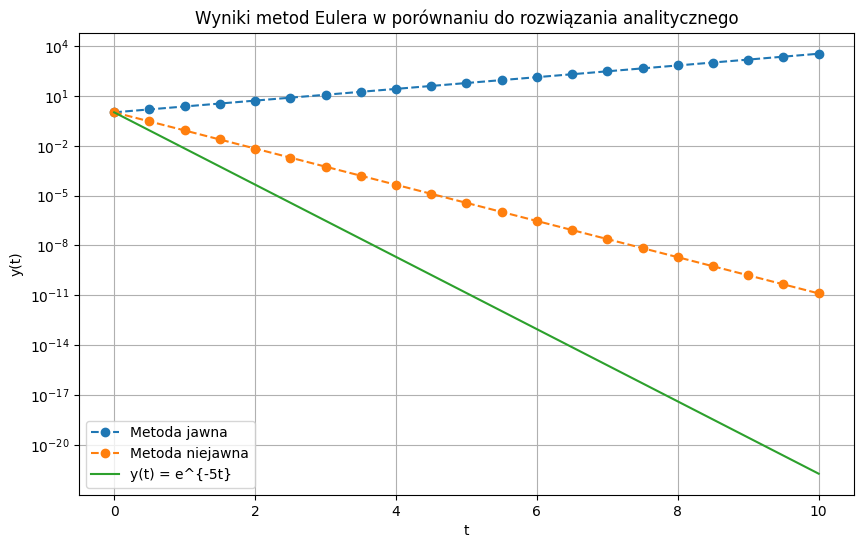

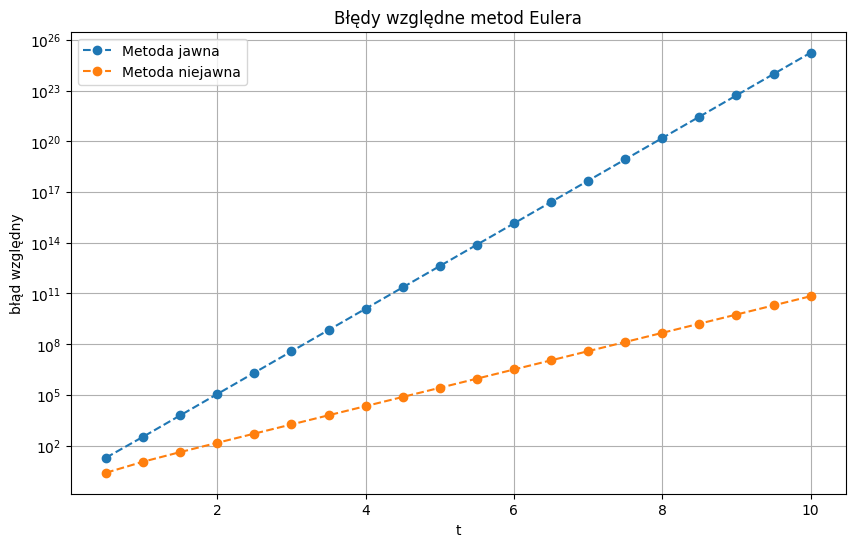

In [2]:
import numpy as np
import matplotlib.pyplot as plt

t_end = 10
h = 0.5
n_steps = int(t_end / h)
t_vals = np.linspace(0, t_end, n_steps + 1)

y_exact = np.exp(-5 * t_vals)

y_expl = np.zeros(n_steps + 1)
y_impl = np.zeros(n_steps + 1)
y_expl[0] = 1
y_impl[0] = 1

for i in range(n_steps):
    y_expl[i+1] = y_expl[i] * (1 - 5 * h)
    y_impl[i+1] = y_impl[i] / (1 + 5 * h)

err_expl = np.abs(y_expl - y_exact) / y_exact
err_impl = np.abs(y_impl - y_exact) / y_exact

plt.figure(figsize=(10, 6))
plt.plot(t_vals, np.abs(y_expl), 'o--', label='Metoda jawna')
plt.plot(t_vals, np.abs(y_impl), 'o--', label='Metoda niejawna')
plt.plot(t_vals, y_exact, '-', label='y(t) = e^{-5t}')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.title('Wyniki metod Eulera w porównaniu do rozwiązania analitycznego')
plt.xlabel('t')
plt.ylabel('y(t)')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t_vals[1:], err_expl[1:], 'o--', label='Metoda jawna')
plt.plot(t_vals[1:], err_impl[1:], 'o--', label='Metoda niejawna')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.title('Błędy względne metod Eulera')
plt.xlabel('t')
plt.ylabel('błąd względny')
plt.show()

## Zadanie 6 - Błędy i rzędy zbieżności

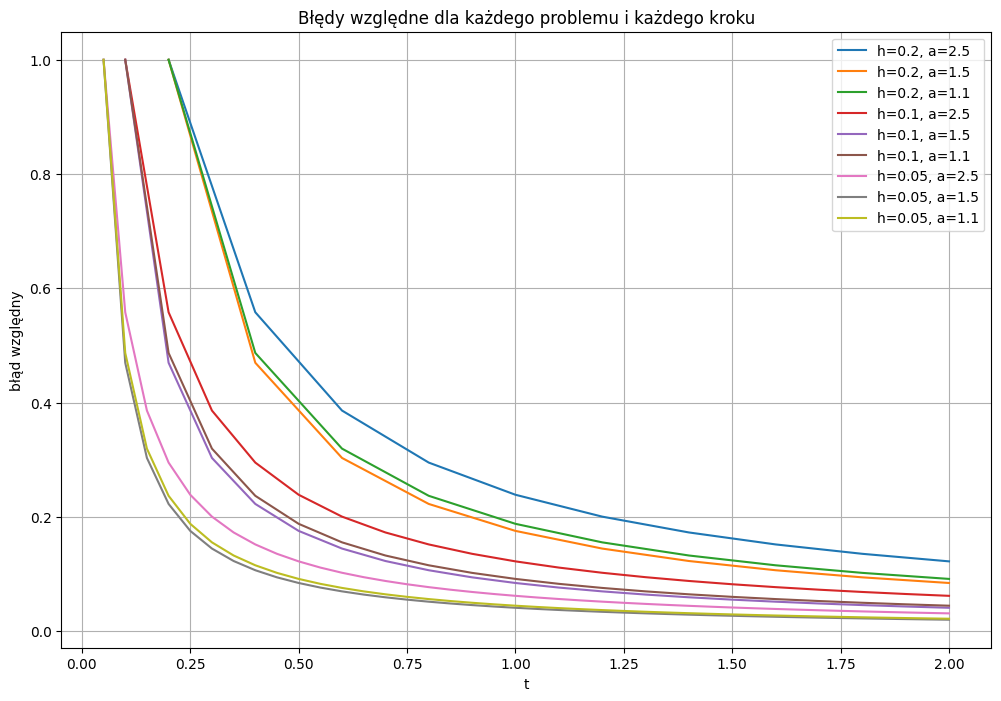

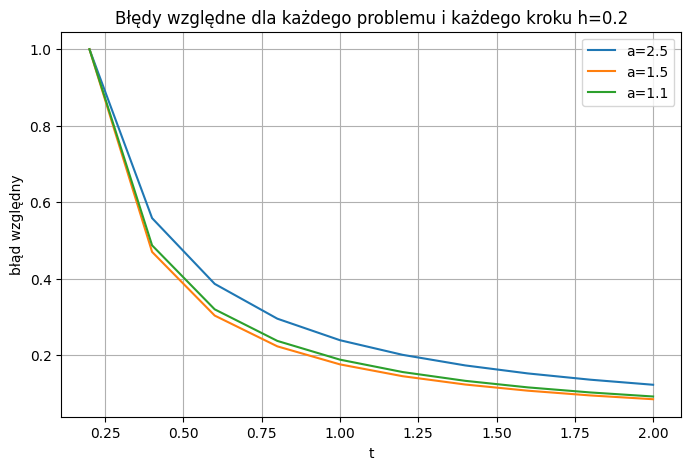

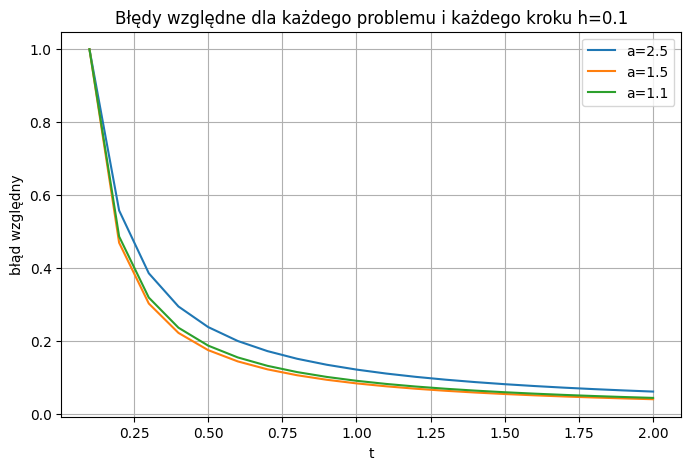

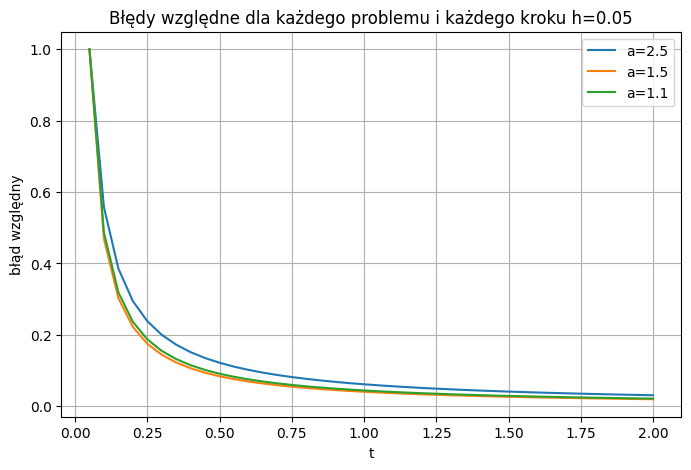

In [3]:
import numpy as np
import matplotlib.pyplot as plt

alphas = [2.5, 1.5, 1.1]
hs = [0.2, 0.1, 0.05]
t_end = 2.0

errors = {h: {a: [] for a in alphas} for h in hs}
t_arrays = {h: np.arange(0, t_end + h, h) for h in hs}

for h in hs:
    t_vals = t_arrays[h]
    for a in alphas:
        y_num = np.zeros(len(t_vals))
        for i in range(len(t_vals) - 1):
            t = t_vals[i]
            deriv = a * (t ** (a - 1)) if t > 0 else (0 if a > 1 else 1e9)
            y_num[i+1] = y_num[i] + h * deriv
        
        y_exact = t_vals ** a
        
        with np.errstate(divide='ignore', invalid='ignore'):
            rel_err = np.abs(y_num - y_exact) / np.abs(y_exact)
            rel_err[0] = 0
            rel_err = np.nan_to_num(rel_err, nan=0.0, posinf=1.0)
        
        errors[h][a] = rel_err

plt.figure(figsize=(12, 8))
for h in hs:
    for a in alphas:
        plt.plot(t_arrays[h][1:], errors[h][a][1:], label=f'h={h}, a={a}')
plt.grid(True)
plt.legend()
plt.title('Błędy względne dla każdego problemu i każdego kroku')
plt.xlabel('t')
plt.ylabel('błąd względny')
plt.show()

for h in hs:
    plt.figure(figsize=(8, 5))
    for a in alphas:
        plt.plot(t_arrays[h][1:], errors[h][a][1:], label=f'a={a}')
    plt.grid(True)
    plt.legend()
    plt.title(f'Błędy względne dla każdego problemu i każdego kroku h={h}')
    plt.xlabel('t')
    plt.ylabel('błąd względny')
    plt.show()